**Lab2-DL: A4-MNIST-Random-Forest.ipynb** (BMED365) | Priority: 3 (optional)

_MNIST classification with Random Forest – establishing an ML baseline_

[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/A4-MNIST-Random-Forest.ipynb)

Last updated: 2025-12-22, A. Lundervold

Use the `bmed365-2026` conda environment or Google Colab

---

## Why Random Forest on images?

### The learning journey: From traditional ML to deep learning

In this series of notebooks we explore **three approaches** to image classification:

```
┌─────────────────┐    ┌─────────────────┐    ┌─────────────────┐
│  A4: Random     │ →  │  A5: MLP        │ →  │  A6: CNN        │
│  Forest         │    │  (Neural nets)  │    │  (Deep learning)│
│ ≈95% accuracy   │    │ ≈97% accuracy   │    │ ≈99% accuracy   │
└─────────────────┘    └─────────────────┘    └─────────────────┘
     BASELINE              IMPROVEMENT           STATE-OF-ART
```

### Why do we start with Random Forest?

| Reason | Explanation |
|--------|-------------|
| **Baseline** | We need something to compare deep learning with |
| **Interpretability** | Random Forest provides insight into which pixels are important |
| **Simplicity** | No hyperparameter tuning of network architecture |
| **Robustness** | Works well without GPU or special hardware |

### Medical relevance

Random Forest is still used in medical AI for:
- **Radiomics**: Classification based on texture features from CT/MR
- **Tabular data**: Patient characteristics, lab values
- **Hybrid models**: Combined with deep learning features

> 💡 **Rule of thumb**: Always start with a simple baseline before moving to complex models!

In [29]:
# === Check runtime environment ===

try:
    import google.colab
    IS_COLAB = True
    print("✅ Running in Google Colab")
except ImportError:
    IS_COLAB = False
    print("💻 Running locally (not Colab)")

💻 Running locally (not Colab)


---

## 1. Imports and preparations

In [30]:
# === Import necessary libraries ===

import numpy as np                    # Numerical computation
import pandas as pd                   # Tabular data
import matplotlib.pyplot as plt       # Visualization
import seaborn as sns                 # Statistical visualization
import os                             # File handling
from pathlib import Path              # Path handling

# Scikit-learn: Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

print("✅ All libraries loaded")

✅ All libraries loaded


---

## 2. Load MNIST data

We use the dataset that was prepared in **A3-MNIST-datacollection.ipynb**. If the file does not exist, we generate it anew.

In [31]:
# === Load MNIST data ===

data_folder = Path('mnist_data')
data_folder.mkdir(exist_ok=True)

# Try compressed file first, then uncompressed
gzip_file = data_folder / 'mnist_20000images.csv.gz'
csv_file = data_folder / 'mnist_20000images.csv'

N_SAMPLES = 20000  # Number of samples to use

if gzip_file.exists():
    print(f"📂 Loading data from compressed file: {gzip_file}")
    mnist_data = pd.read_csv(gzip_file)
elif csv_file.exists():
    print(f"📂 Loading data from CSV file: {csv_file}")
    mnist_data = pd.read_csv(csv_file)
else:
    print(f"⏳ Generating MNIST data ({N_SAMPLES} samples) from PyTorch...")
    from torchvision import datasets
    import torchvision.transforms as transforms
    
    # Download MNIST
    mnist_train = datasets.MNIST(root='./data', train=True, download=True,
                                  transform=transforms.ToTensor())
    mnist_test = datasets.MNIST(root='./data', train=False, download=True,
                                 transform=transforms.ToTensor())
    
    # Convert and combine
    X_train = mnist_train.data.numpy().reshape(60000, -1) / 255.0
    X_test = mnist_test.data.numpy().reshape(10000, -1) / 255.0
    y_train = mnist_train.targets.numpy()
    y_test = mnist_test.targets.numpy()
    
    X = np.concatenate([X_train, X_test])
    y = np.concatenate([y_train, y_test])
    
    # Take random sample
    np.random.seed(42)
    indices = np.random.choice(len(X), N_SAMPLES, replace=False)
    
    # Create DataFrame
    columns = [f'pixel_{i}' for i in range(784)]
    mnist_data = pd.DataFrame(X[indices], columns=columns)
    mnist_data['label'] = y[indices]
    
    # Save compressed
    mnist_data.to_csv(gzip_file, index=False, compression='gzip')
    print(f"✅ Data saved to {gzip_file}")

print(f"\n📊 Dataset dimensions: {mnist_data.shape}")
print(f"   {mnist_data.shape[0]} images × {mnist_data.shape[1]-1} pixels + 1 label")

📂 Loading data from compressed file: mnist_data/mnist_20000images.csv.gz

📊 Dataset dimensions: (20000, 785)
   20000 images × 784 pixels + 1 label


### Stratified train/test split

We split the data so that the class distribution is preserved in both parts.

In [32]:
# === Split into training and test data ===

# Find the label column (can be named 'label' or 'etikett')
label_column = 'label' if 'label' in mnist_data.columns else 'etikett'

# Stratified split: 80% training, 20% test
train_data, test_data = train_test_split(
    mnist_data,
    test_size=0.2,
    random_state=42,
    stratify=mnist_data[label_column]
)

# Separate features and labels
X_train = train_data.drop(label_column, axis=1)
y_train = train_data[label_column]
X_test = test_data.drop(label_column, axis=1)
y_test = test_data[label_column]

print(f"📊 Data split:")
print(f"   Training: {len(X_train)} images")
print(f"   Test:     {len(X_test)} images")

📊 Data split:
   Training: 16000 images
   Test:     4000 images


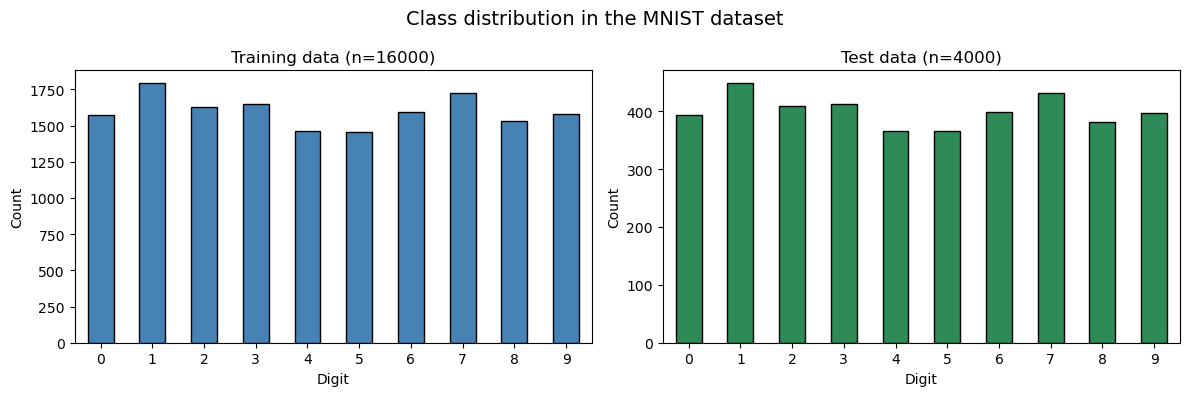

✅ Stratified split preserves class balance


In [33]:
# === Visualize class distribution ===

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training data
y_train.value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title(f'Training data (n={len(y_train)})', fontsize=12)
axes[0].set_xlabel('Digit')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(range(10), rotation=0)

# Test data
y_test.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='black'
)
axes[1].set_title(f'Test data (n={len(y_test)})', fontsize=12)
axes[1].set_xlabel('Digit')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(range(10), rotation=0)

plt.suptitle('Class distribution in the MNIST dataset', fontsize=14)
plt.tight_layout()
plt.show()

print("✅ Stratified split preserves class balance")

---

## 3. Visualize examples

Let's look at some of the images we are going to classify.

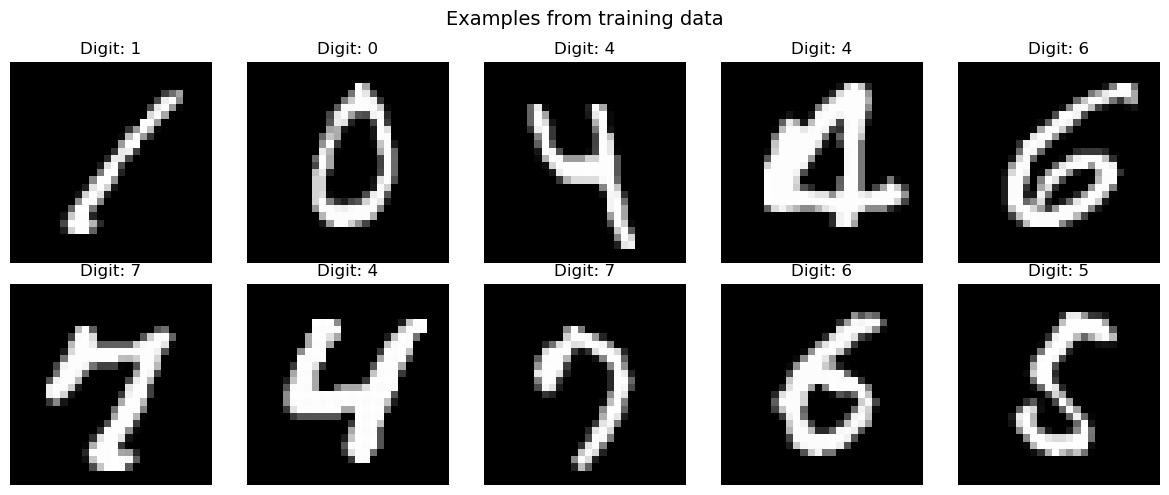

In [34]:
# === Show example images ===

def show_digit(data, index, labels=None, prediction=None):
    """Displays a single MNIST digit."""
    # Get pixel data (all columns except label)
    pixel_columns = [c for c in data.columns if c != label_column]
    image = data.iloc[index][pixel_columns].values.reshape(28, 28)
    
    plt.imshow(image, cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
    
    true_label = int(data.iloc[index][label_column])
    if prediction is not None:
        plt.title(f'Pred: {prediction}\nTrue: {true_label}')
    else:
        plt.title(f'Digit: {true_label}')

# Show 10 random examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

np.random.seed(123)
indices = np.random.choice(len(train_data), 10, replace=False)

for i, idx in enumerate(indices):
    plt.sca(axes[i])
    show_digit(train_data.reset_index(drop=True), i)

plt.suptitle('Examples from training data', fontsize=14)
plt.tight_layout()
plt.show()

---

## 4. Train the Random Forest model

### How does Random Forest work on images?

Random Forest treats each image as a **flat vector** with 784 features (pixels):

```
28×28 image  →  [p₀, p₁, p₂, ..., p₇₈₃]  →  Random Forest  →  Class (0-9)
```

**Limitation**: The model does not see spatial structure – only individual pixel values!

In [35]:
# === Train Random Forest ===

print("🌲 Training Random Forest classifier...")
print(f"   Number of training examples: {len(X_train)}")
print(f"   Number of features (pixels): {X_train.shape[1]}")

# Create and train the model
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    random_state=42,       # Reproducibility
    n_jobs=-1              # Use all CPU cores
)

rf_model.fit(X_train, y_train)

print("\n✅ Model trained!")
print(f"   Number of trees: {rf_model.n_estimators}")
print(f"   Number of classes: {rf_model.n_classes_}")

🌲 Training Random Forest classifier...
   Number of training examples: 16000
   Number of features (pixels): 784

✅ Model trained!
   Number of trees: 100
   Number of classes: 10


---

## 5. Evaluate the model

### Classification report

We use standard evaluation metrics from medical diagnostics:
- **Precision**: How many of the predicted positives are actually positive?
- **Recall** (sensitivity): How many of the actual positives were found?
- **F1-score**: Harmonic mean of precision and recall

In [36]:
# === Evaluate the model ===

print("📊 Evaluating the model on test data...\n")

# Predict on test data
y_pred = rf_model.predict(X_test)

# Classification report
print("Classification report:")
print("="*60)
print(classification_report(y_test, y_pred, 
                            target_names=[f'Digit {i}' for i in range(10)]))

📊 Evaluating the model on test data...

Classification report:
              precision    recall  f1-score   support

     Digit 0       0.96      0.97      0.97       393
     Digit 1       0.98      0.99      0.98       448
     Digit 2       0.94      0.97      0.95       408
     Digit 3       0.93      0.91      0.92       412
     Digit 4       0.96      0.96      0.96       366
     Digit 5       0.95      0.95      0.95       365
     Digit 6       0.98      0.98      0.98       399
     Digit 7       0.95      0.96      0.95       431
     Digit 8       0.92      0.91      0.92       382
     Digit 9       0.94      0.91      0.93       396

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000



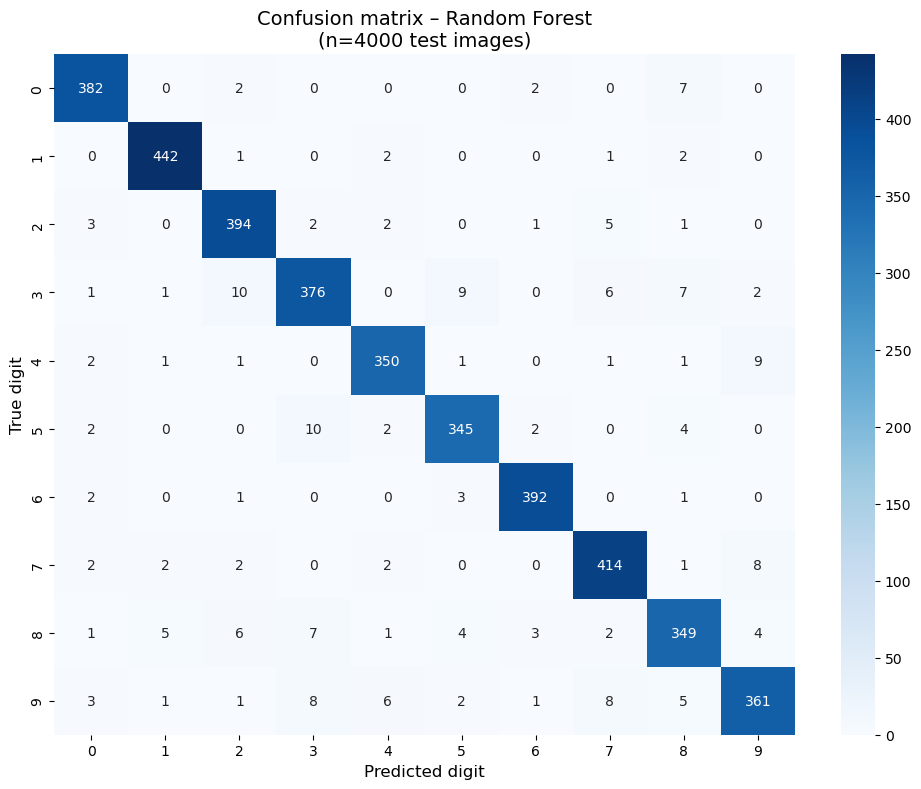


📊 Summary:
   Accuracy: 95.1%
   Error rate: 4.9%


In [37]:
# === Confusion matrix ===

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))

plt.title(f'Confusion matrix – Random Forest\n(n={len(y_test)} test images)', 
          fontsize=14)
plt.xlabel('Predicted digit', fontsize=12)
plt.ylabel('True digit', fontsize=12)
plt.tight_layout()
plt.show()

# Summary metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\n📊 Summary:")
print(f"   Accuracy: {accuracy:.1%}")
print(f"   Error rate: {1-accuracy:.1%}")

### Interpretation of results

**What does the confusion matrix show?**
- Diagonal = correct predictions
- Off-diagonal = errors (confusion between digits)

**Typical errors:**
- 8 ↔ 5: Similar curved structure
- 4 ↔ 9: Similar top
- 3 ↔ 8: Curved shape

> 💡 **Baseline established**: ~95% accuracy. Can we do better with neural networks?

### ROC curves (one-vs-all)

The ROC curve shows the trade-off between sensitivity and specificity.

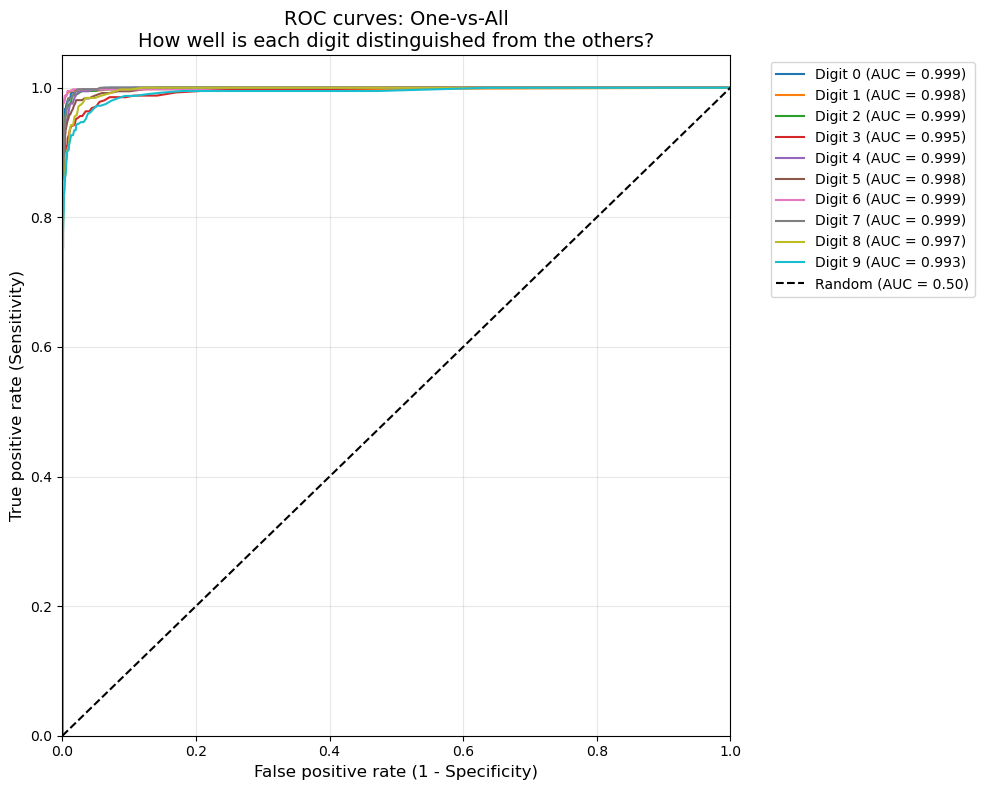


📊 Mean ROC AUC: 0.9975


In [38]:
# === ROC curves for each digit ===

# Get probability predictions
y_prob = rf_model.predict_proba(X_test)

# Binarize labels for ROC calculation
y_test_bin = label_binarize(y_test, classes=range(10))

# Calculate ROC for each digit
plt.figure(figsize=(10, 8))

roc_auc = {}
for digit in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, digit], y_prob[:, digit])
    roc_auc[digit] = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Digit {digit} (AUC = {roc_auc[digit]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate (1 - Specificity)', fontsize=12)
plt.ylabel('True positive rate (Sensitivity)', fontsize=12)
plt.title('ROC curves: One-vs-All\nHow well is each digit distinguished from the others?', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mean_auc = np.mean(list(roc_auc.values()))
print(f"\n📊 Mean ROC AUC: {mean_auc:.4f}")

---

## 6. Feature importance – Which pixels are most important?

A major advantage of Random Forest is **interpretability**. We can see which pixels the model uses most for making decisions.

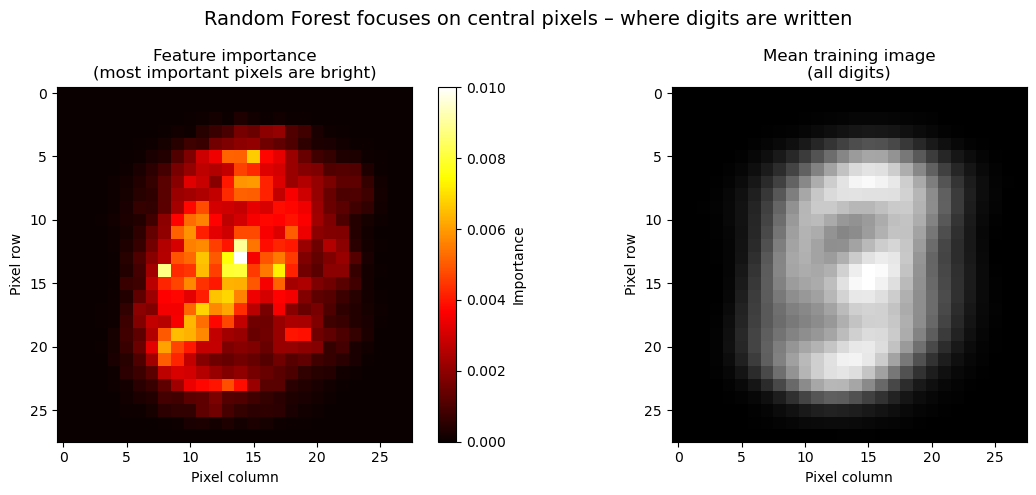

In [39]:
# === Visualize feature importance ===

# Get feature importance and reshape to image dimensions
importance = rf_model.feature_importances_
importance_image = importance.reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Feature importance heatmap
im = axes[0].imshow(importance_image, cmap='hot')
axes[0].set_title('Feature importance\n(most important pixels are bright)', fontsize=12)
axes[0].set_xlabel('Pixel column')
axes[0].set_ylabel('Pixel row')
plt.colorbar(im, ax=axes[0], label='Importance')

# Compare with average digit
mean_image = X_train.values.mean(axis=0).reshape(28, 28)
axes[1].imshow(mean_image, cmap='gray')
axes[1].set_title('Mean training image\n(all digits)', fontsize=12)
axes[1].set_xlabel('Pixel column')
axes[1].set_ylabel('Pixel row')

plt.suptitle('Random Forest focuses on central pixels – where digits are written', fontsize=14)
plt.tight_layout()
plt.show()

---

## 7. Analyze misclassifications

Let's look at some examples where the model makes mistakes.

🔍 Number of misclassifications: 195 of 4000 (4.9%)



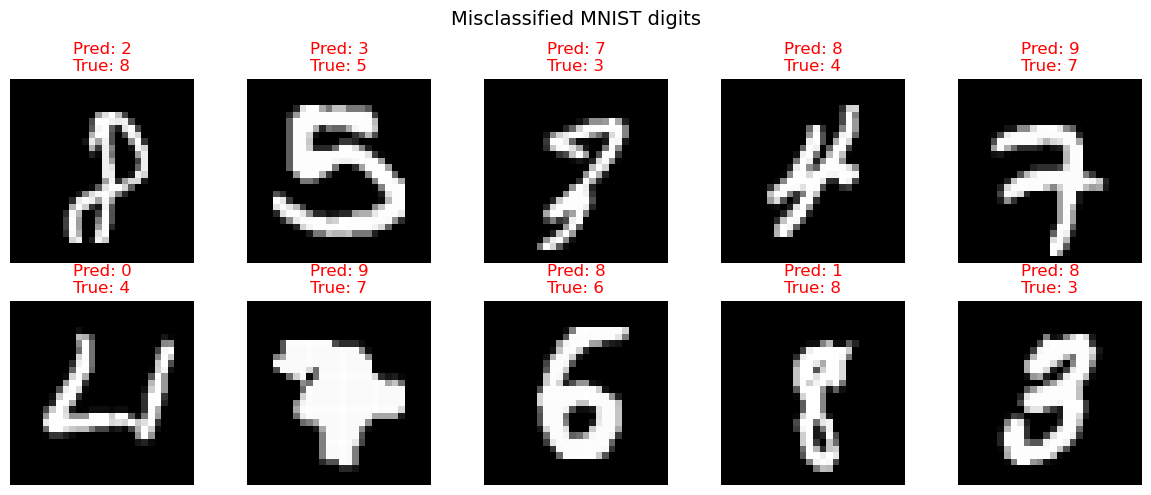

In [40]:
# === Show misclassified examples ===

# Find errors
error_indices = np.where(y_test.values != y_pred)[0]
print(f"🔍 Number of misclassifications: {len(error_indices)} of {len(y_test)} ({len(error_indices)/len(y_test):.1%})\n")

# Show 10 misclassified examples
n_show = min(10, len(error_indices))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(n_show):
    idx = error_indices[i]
    image = X_test.iloc[idx].values.reshape(28, 28)
    
    axes[i].imshow(image, cmap='gray')
    axes[i].axis('off')
    true = y_test.iloc[idx]
    pred = y_pred[idx]
    axes[i].set_title(f'Pred: {pred}\nTrue: {true}', 
                      color='red' if pred != true else 'black')

plt.suptitle('Misclassified MNIST digits', fontsize=14)
plt.tight_layout()
plt.show()

---

## 8. Save the model

In [41]:
# === Save the model ===

import joblib

model_file = data_folder / 'mnist_random_forest.joblib'
joblib.dump(rf_model, model_file)

print(f"✅ Model saved to: {model_file}")
print(f"   File size: {model_file.stat().st_size / 1e6:.1f} MB")

✅ Model saved to: mnist_data/mnist_random_forest.joblib
   File size: 50.5 MB


---

## Summary and next steps

### What we have achieved

| Metric | Random Forest |
|--------|---------------|
| **Accuracy** | ~95% |
| **ROC AUC** | ~0.99 |
| **Training time** | Seconds |
| **Interpretability** | High (feature importance) |

### Limitations

Random Forest does not see **spatial structure** in images:
- Treats pixels independently
- No understanding of neighborhood
- Rotation/translation gives completely different features

### Next step: Comparison

```
┌─────────────────────────────────────────────────────────────┐
│  Model             Accuracy      Spatial structure   GPU   │
├─────────────────────────────────────────────────────────────┤
│  Random Forest     ~95%          No                  No    │
│  MLP (A5)          ~97%          No                  No    │
│  CNN (A6)          ~99%          YES! ✓              Optional│
└─────────────────────────────────────────────────────────────┘
```

> **Continue to A5-MNIST-MLP.ipynb** to see how neural networks improve the results!

---

## 🎯 Exercises

### Exercise 1: Change the number of trees
Try training with `n_estimators=10` and `n_estimators=500`. How does this affect accuracy and training time?

<details>
<summary>💡 Show answer</summary>

```python
import time

for n_trees in [10, 100, 500]:
    start = time.time()
    rf = RandomForestClassifier(n_estimators=n_trees, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    elapsed = time.time() - start
    acc = accuracy_score(y_test, rf.predict(X_test))
    print(f"n_trees={n_trees}: Accuracy={acc:.3f}, Time={elapsed:.1f}s")
```
More trees → marginally better accuracy, but longer training time.

</details>

### Exercise 2: Which digits are the most difficult?
Use the confusion matrix to identify the three digit pairs with the most confusions.

<details>
<summary>💡 Show answer</summary>

Look at the cells outside the diagonal in the confusion matrix. Typically the most difficult pairs are:
1. 8 ↔ 5 (similar curves)
2. 4 ↔ 9 (similar top)
3. 3 ↔ 8 (curved shape)

</details>